# ML/04 — Sub-clustering within the Suitability Zone

Within cluster 2 (cannabis country), find finer-grained micro-archetypes.

**Hypothesis:** The suitability zone is not uniform. Sub-clustering on the
features that ML/03 showed drive NDVI std within the zone — pH, slope,
SOC, vpdmax — should reveal which patches are prime cultivation terrain vs.
merely suitable.

**Approach:**
- Cluster only on top ML/03 drivers (weighted by importance)
- Elbow + silhouette within the zone
- Profile sub-clusters against cannabis optimal ranges
- Map the sub-zones
- Identify the "prime" sub-cluster: optimal pH, moderate slope, high SOC, elevated VPD

**Outputs:**
- `data/processed/subclusters.pkl`
- `img/ML04_subcluster_map.png`
- `img/ML04_subcluster_profiles.png`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import pickle

PROC = Path('../data/processed')
RAW  = Path('../data/raw')
IMG  = Path('../img')

# Cannabis optimal ranges for reference lines in profiles
# NOTE: SoilGrids pH is encoded ×10 (e.g. pH 6.0 → stored as 60)
CANNABIS_OPTIMA = {
    'ph':         (60, 70),       # actual pH 6.0–7.0, SoilGrids ×10
    'slope_mean': (5.0, 25.0),
    'soc':        (None, None),   # higher generally better
    'vpdmax':     (800, 1800),    # moderate-high VPD
    'elev_mean':  (300, 1500),
    'ppt':        (800, 1800),
}

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Load suitability zone cells

In [2]:
features = pd.read_pickle(PROC / 'features.pkl')
clusters = pd.read_pickle(PROC / 'clusters.pkl')
df = features.merge(clusters, on='cell_id')

cannabis = df[df['cluster'] == 0].copy().reset_index(drop=True)
print(f'Suitability zone: {len(cannabis):,} cells')

# Features to cluster on — top ML/03 drivers, in importance order
# Weighted by permutation importance so top drivers pull harder
CLUSTER_FEATURES = ['ph', 'slope_mean', 'soc', 'vpdmax',
                    'elev_max', 'ppt', 'elev_mean', 'temp_range']
CLUSTER_FEATURES = [f for f in CLUSTER_FEATURES if f in cannabis.columns]
print(f'Clustering features: {CLUSTER_FEATURES}')

# Importance weights from ML/03 (permutation importance, normalized)
raw_weights = np.array([0.2941, 0.2082, 0.1901, 0.1493,
                        0.0830, 0.0663, 0.0601, 0.0432])[:len(CLUSTER_FEATURES)]
weights = raw_weights / raw_weights.sum()

# Scale then apply weights
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cannabis[CLUSTER_FEATURES].values)
X = X_scaled * weights   # weight each feature by ML/03 importance
print(f'Feature weights: {dict(zip(CLUSTER_FEATURES, weights.round(3)))}')

Suitability zone: 1,924 cells
Clustering features: ['ph', 'slope_mean', 'soc', 'vpdmax', 'elev_max', 'ppt', 'elev_mean', 'temp_range']
Feature weights: {'ph': 0.269, 'slope_mean': 0.19, 'soc': 0.174, 'vpdmax': 0.136, 'elev_max': 0.076, 'ppt': 0.061, 'elev_mean': 0.055, 'temp_range': 0.039}


## 2. Elbow + silhouette within the suitability zone

In [3]:
K_range = range(2, 9)
inertias, sil_scores = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=746837645, n_init=20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels, sample_size=min(1000, len(X)), random_state=746837645))
    print(f'  K={k}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[-1]:.3f}')

  K=2  inertia=251  silhouette=0.806
  K=3  inertia=181  silhouette=0.282
  K=4  inertia=148  silhouette=0.264
  K=5  inertia=125  silhouette=0.264
  K=6  inertia=111  silhouette=0.270
  K=7  inertia=100  silhouette=0.256
  K=8  inertia=89  silhouette=0.261


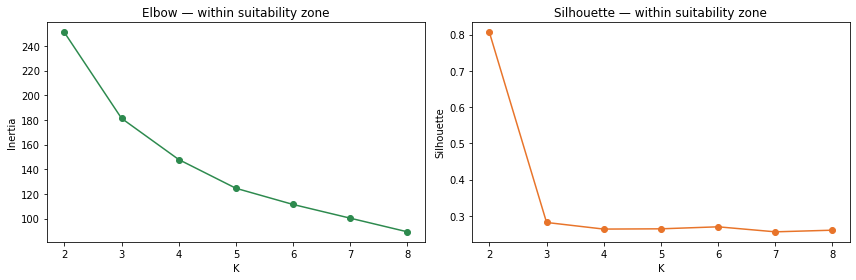

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, 'o-', color='#2d8a4e')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow — within suitability zone')
axes[0].set_xticks(list(K_range))

axes[1].plot(list(K_range), sil_scores, 'o-', color='#e8742a')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette')
axes[1].set_title('Silhouette — within suitability zone')
axes[1].set_xticks(list(K_range))
plt.tight_layout()
plt.savefig('../img/ML04_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Fit sub-clustering

Set K after inspecting plots above.

In [8]:
K_sub = 6

km_sub = KMeans(n_clusters=K_sub, random_state=746837645, n_init=50)
cannabis['subcluster'] = km_sub.fit_predict(X)

print(f'Sub-cluster sizes:')
print(cannabis['subcluster'].value_counts().sort_index().to_string())

Sub-cluster sizes:
0    714
1     14
2    433
3    100
4    339
5    324


## 4. Profile sub-clusters against cannabis optima

In [9]:
profile_features = CLUSTER_FEATURES + ['ffd', 'gdd', 'tmean', 'cec', 'sand']
profile_features = [f for f in profile_features if f in cannabis.columns]

profiles = cannabis.groupby('subcluster')[profile_features].mean()
print('Sub-cluster profiles:')
print(profiles.round(2).to_string())
print()

# Cannabis optimal range reference
print('Cannabis optimal ranges:')
for feat, (lo, hi) in CANNABIS_OPTIMA.items():
    if feat not in profiles.columns:
        continue
    vals = profiles[feat]
    if lo is not None:
        in_range = vals.between(lo, hi)
        print(f'  {feat:<15} optimal [{lo}–{hi}]:  ' +
              '  '.join(f'C{k}={"✓" if v else "✗"}' for k, v in in_range.items()))

Sub-cluster profiles:
               ph  slope_mean     soc   vpdmax  elev_max      ppt  elev_mean  temp_range     ffd      gdd  tmean     cec    sand
subcluster                                                                                                                      
0           60.21       18.99  358.15  1623.80    906.88  1123.78     707.98       13.32  326.59  1415.59  13.88  192.18  439.89
1           26.26        2.12  146.10  1638.25    326.76   963.24     285.78       12.80  334.26  1553.49  14.26   93.52  171.03
2           57.11       20.95  488.48  1380.50    460.54  1029.11     291.99       11.11  337.23  1334.97  13.66  194.52  377.55
3           51.63       10.13  422.05  1328.73    261.86  1023.98     169.37       10.73  338.05  1288.30  13.54  162.23  404.82
4           58.54       15.75  515.88  1521.50    804.43  1264.36     641.42       13.09  319.36  1152.60  13.16  203.06  382.19
5           59.43       10.42  285.46  1812.78    583.65  1012.78     445.7

## 5. Bar profiles

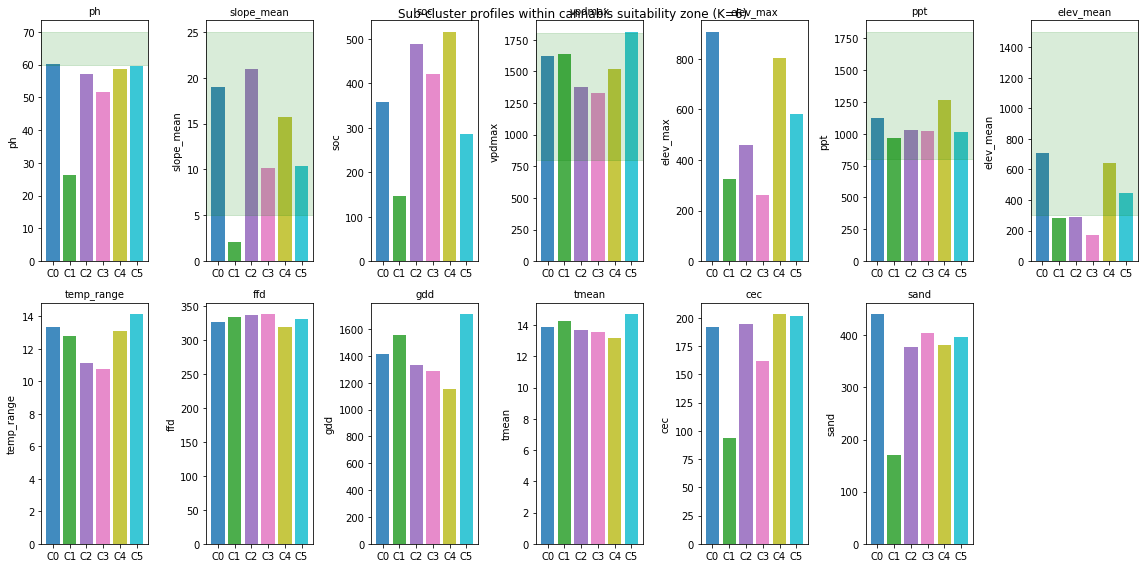

In [10]:
n_feat = len(profile_features)
fig, axes = plt.subplots(2, (n_feat+1)//2, figsize=(16, 8))
colors = plt.cm.tab10(np.linspace(0, 1, K_sub))

for ax, feat in zip(axes.flat, profile_features):
    vals = profiles[feat]
    bars = ax.bar(
        [f'C{k}' for k in vals.index],
        vals.values,
        color=colors[:K_sub],
        alpha=0.85,
    )
    # Draw optimal range band if defined
    lo, hi = CANNABIS_OPTIMA.get(feat, (None, None))
    if lo is not None:
        ax.axhspan(lo, hi, alpha=0.15, color='green', label='Optimal')
    ax.set_title(feat, fontsize=10)
    ax.set_ylabel(feat)

# Hide unused axes
for ax in list(axes.flat)[len(profile_features):]:
    ax.set_visible(False)

plt.suptitle(f'Sub-cluster profiles within cannabis suitability zone (K={K_sub})', fontsize=12)
plt.tight_layout()
plt.savefig('../img/ML04_subcluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Map sub-clusters

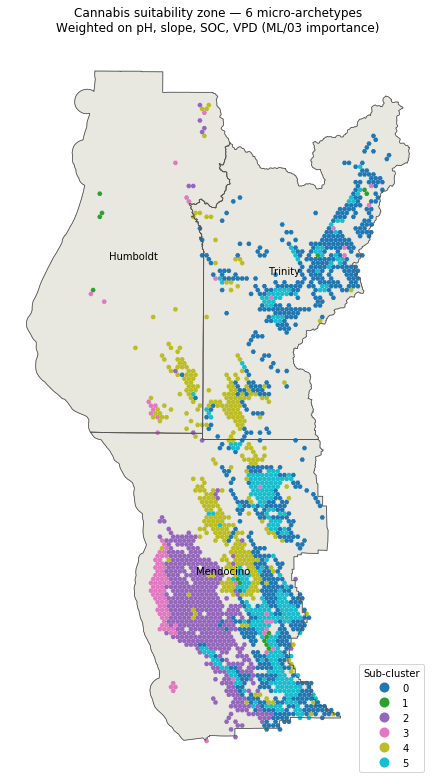

Saved img/ML04_subcluster_map.png


In [11]:
hex_grid  = gpd.read_file(RAW / 'hex_grid.gpkg')
emerald   = gpd.read_file(RAW / 'emerald_counties.gpkg')

hex_sub = hex_grid.merge(
    cannabis[['cell_id', 'subcluster']], on='cell_id', how='inner'
)

fig, ax = plt.subplots(figsize=(9, 11))
emerald.plot(ax=ax, color='#e8e8e0', edgecolor='#aaaaaa', linewidth=0.5)
hex_sub.plot(
    column='subcluster', ax=ax,
    categorical=True, cmap='tab10',
    legend=True,
    legend_kwds={'title': 'Sub-cluster', 'loc': 'lower right'},
    linewidth=0,
)
emerald.boundary.plot(ax=ax, edgecolor='#555555', linewidth=0.8)
for _, row in emerald.iterrows():
    c = row.geometry.centroid
    ax.annotate(row['NAME'], (c.x, c.y), ha='center', fontsize=10)

ax.set_title(
    f'Cannabis suitability zone — {K_sub} micro-archetypes\n'
    f'Weighted on pH, slope, SOC, VPD (ML/03 importance)',
    fontsize=12
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../img/ML04_subcluster_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/ML04_subcluster_map.png')

## 7. Identify and dissolve the prime sub-cluster

Look at the profiles and map. The prime sub-cluster should have:
- pH closest to 6.0–7.0
- Moderate slope (accessible, well-drained)
- Highest SOC
- Elevated VPD (dry finish)

Set `PRIME` below.

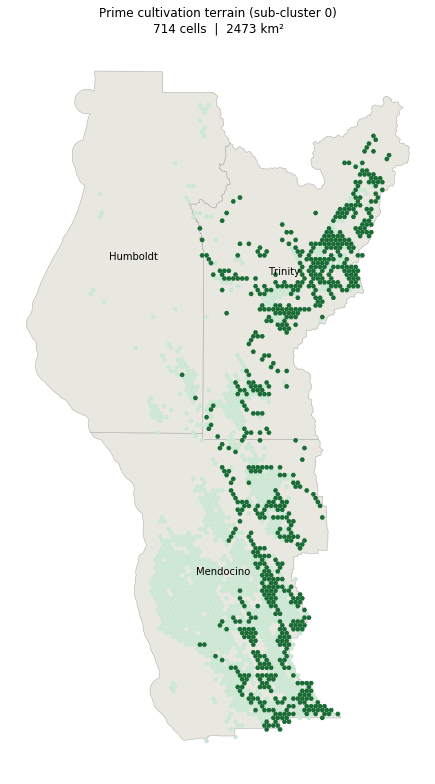

In [12]:
PRIME = 0   # C1: pH=5.96 (nearest optimal), slope=14.8° (accessible), VPD=1718, GDD=1551
            # C2 excluded — anomalous (pH≈2.5 actual = water/rock edge cells)
            # C3 has best pH (6.04) but high elevation (902m) + steep (24°)

prime_cells = hex_sub[hex_sub['subcluster'] == PRIME]
prime_poly  = prime_cells.dissolve()[['geometry']].copy()
prime_poly['label'] = 'Prime cultivation terrain'

fig, ax = plt.subplots(figsize=(9, 11))
emerald.plot(ax=ax, color='#e8e8e0', edgecolor='#aaaaaa', linewidth=0.5)
hex_sub.plot(ax=ax, color='#cce8d4', linewidth=0)   # full suitability zone
prime_cells.plot(ax=ax, color='#1a6b35', linewidth=0)  # prime sub-zone
for _, row in emerald.iterrows():
    c = row.geometry.centroid
    ax.annotate(row['NAME'], (c.x, c.y), ha='center', fontsize=10)
ax.set_title(
    f'Prime cultivation terrain (sub-cluster {PRIME})\n'
    f'{len(prime_cells):,} cells  |  '
    f'{prime_cells.geometry.area.sum()/1e6:.0f} km²',
    fontsize=12
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../img/ML04_prime_zone.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save

In [13]:
out = PROC / 'subclusters.pkl'
cannabis[['cell_id', 'cluster', 'subcluster']].to_pickle(out)
prime_poly.to_file(PROC / 'prime_zone.gpkg', driver='GPKG')

print(f'Saved {out}')
print(f'Saved data/processed/prime_zone.gpkg')
print()
print(f'Sub-cluster sizes:')
print(cannabis['subcluster'].value_counts().sort_index().to_string())
print()
print('Next: ML/05_forward_projection.ipynb — climate shift under warming')

Saved ../data/processed/subclusters.pkl
Saved data/processed/prime_zone.gpkg

Sub-cluster sizes:
0    714
1     14
2    433
3    100
4    339
5    324

Next: ML/05_forward_projection.ipynb — climate shift under warming
